## 3. INSIGHTS Y SEGMENTACIÓN ACCIONABLE

**Objetivo:** traducir el análisis EDA en decisiones concretas de marketing y segmentación de audiencias.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. CARGA DE DATOS
df = pd.read_csv("data_limpia.csv")

### 1. Segmentación por Rendimiento

Categorizamos las campañas en base a su éxito relativo (Open Rate y Click Rate).

In [33]:
invalid_campaigns = df[df["sent"] < 50]["campaign_name"]    

def segmentar_rendimiento(row):
    
    if row['trackable_open_rate'] >= 80 and row['click_rate'] >= 30 and row['campaign_name'] not in invalid_campaigns:
        return 'Top Performance'
    elif row['trackable_open_rate'] >= 60 and row['campaign_name'] not in invalid_campaigns:
        return 'Buen Alcance, Interés Medio'
    elif row['click_rate'] >= 15 and row['campaign_name'] not in invalid_campaigns:
        return 'Alcance Bajo, Alta Conversión'
    else:
        return 'Bajo Rendimiento'

df['segmento_rendimiento'] = df.apply(segmentar_rendimiento, axis=1)
df['segmento_rendimiento'].value_counts()

segmento_rendimiento
Buen Alcance, Interés Medio    23
Bajo Rendimiento               19
Top Performance                12
Name: count, dtype: int64

<Axes: xlabel='segmento_rendimiento'>

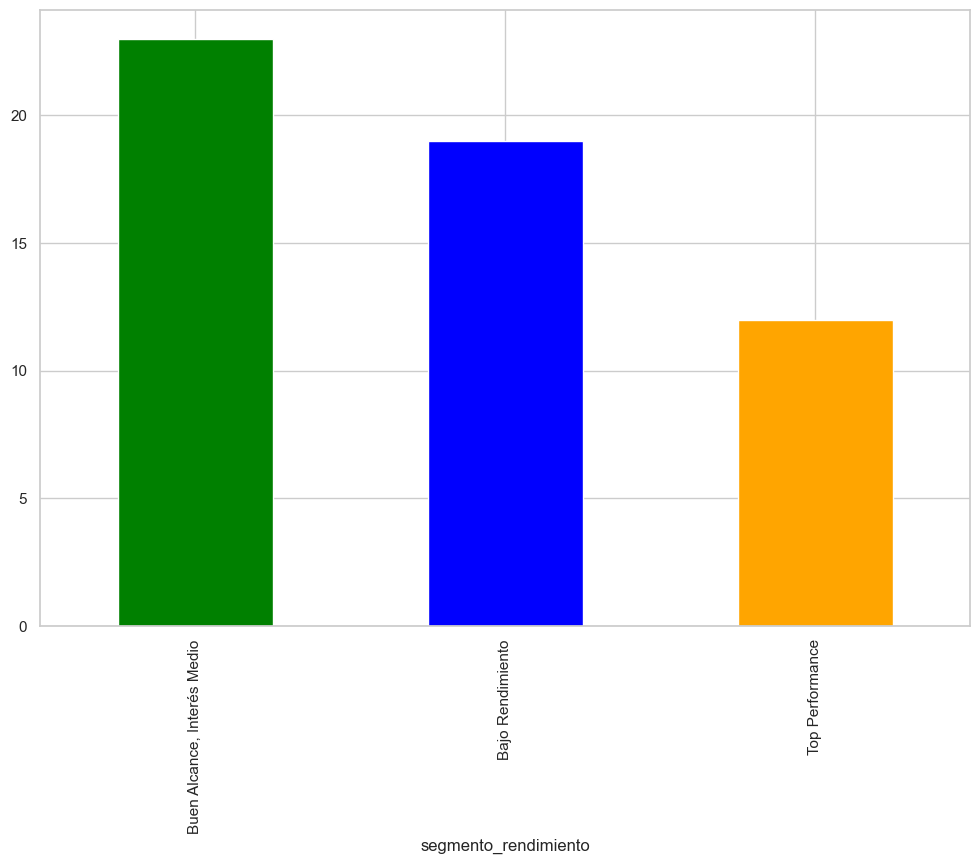

In [34]:
df['segmento_rendimiento'].value_counts().plot(kind='bar', color=['green', 'blue', 'orange', 'red'])

In [35]:
df['top_campaign'] = df['segmento_rendimiento'].apply(lambda x: 1 if x == 'Top Performance' else 0)

df.sample(1)

,campaign_id,campaign_name,sending_date,subject,sent,non_delivered_rate,total_opens,opens,trackable_open_rate,apple_mpp_opens,...,soft_bounces_rate,complaints_rate,year,month,day,weekday,tipo_campaña,tipo_publico,segmento_rendimiento,top_campaign
53,102,newsletter artistas febrero,2026-02-04,nuevas convocatorias,280,1.43,546,209,75.72,42,...,1.43,0.0,2026,2,4,2,convocatorias,artistas,"Buen Alcance, Interés Medio",0


In [39]:
kpis_top_campaigns = (
    df[df['top_campaign'] == 1]
    .groupby(['tipo_publico', 'tipo_campaña', 'subject'])[['click_rate', 'trackable_open_rate']]
    .mean()
    .sort_values(by='click_rate', ascending=False)
)

display(kpis_top_campaigns)

click_rate  \
tipo_publico tipo_campaña  subject                                          
artistas     otros         artistas seleccionados                  88.890   
             invitacion    participación piloto engira​!           59.830   
all          invitacion    participación piloto engira!            52.170   
artistas     convocatorias convocatorias abiertas                  48.370   
                           nuevas convocatorias!                   43.300   
                           no te pierdas estas convocatorias!      41.940   
                           nuevas convocatorias y una "demo"       40.790   
                           nuevas convocatorias                    36.765   
             invitacion    participación piloto engira!            33.330   

                                                               trackable_open_rate  
tipo_publico tipo_campaña  subject                                                  
artistas     otros         artistas seleccionados                         100.0000  
             invitacion    participación piloto engira​!                  100.0000  
all          invitacion    participación piloto engira!                   100.0000  
artistas     convocatorias convocatorias abiertas                         100.0000  
                           nuevas convocatorias!                          100.0000  
                           no te pierdas estas convocatorias!             100.0000  
                           nuevas convocatorias y una "demo"              100.0000  
                           nuevas convocatorias                            99.4875  
             invitacion    participación piloto engira!                   100.0000

### 2. Análisis por Temática del Asunto

Detectamos keywords en los asuntos para entender qué temas traccionan mejor.

In [42]:
keywords = {
    'convocatoria': ['convocatoria', 'abiertas', 'plazo'],
    'webinar_formacion': ['webinar', 'demo', 'taller', 'programa'],
    'evento_feria': ['feria', 'mercartes', 'madferia', 'dferia'],
    'registro_plataforma': ['registro', 'completa', 'perfil'],
    'descubrimiento': ['descubre', 'descobreix', 'artistas', 'destacado']
}

def detectar_tematica(subject):
    subject = str(subject).lower()
    for theme, terms in keywords.items():
        if any(term in subject for term in terms):
            return theme
    return 'otros'

df['tematica_asunto'] = df['subject'].apply(detectar_tematica)

tematica_stats = df.groupby(['tematica_asunto', 'tipo_publico'])[['click_rate','trackable_open_rate']].mean().sort_values('click_rate', ascending=False)
tematica_stats

click_rate  trackable_open_rate
tematica_asunto     tipo_publico                                  
otros               artistas        46.580000           100.000000
convocatoria        artistas        33.757333            92.268667
descubrimiento      artistas        31.886667            73.466667
otros               all             26.085000           100.000000
registro_plataforma all             17.420000            90.275000
webinar_formacion   artistas        12.191667            84.750000
descubrimiento      all              7.140000           100.000000
                    programadores    5.622000            30.120000
evento_feria        all              5.434000            72.678000
otros               programadores    5.315000            49.425000
webinar_formacion   programadores    3.397500            26.110000
evento_feria        artistas         1.770000            59.210000
                    programadores    0.720000            30.430000
webinar_formacion   all              0.000000            17.140000

### 3. Visualización Estratégica

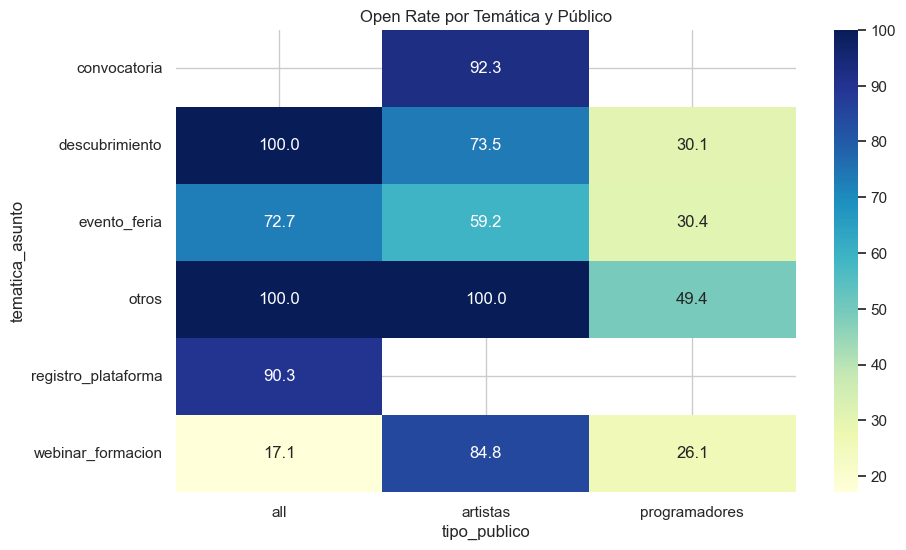

In [38]:
plt.figure(figsize=(10, 6))
pivot_tematica = df.pivot_table(values='trackable_open_rate', index='tematica_asunto', columns='tipo_publico', aggfunc='mean')
sns.heatmap(pivot_tematica, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Open Rate por Temática y Público')
plt.show()

### 4. Insights Principales

1. **Dominio de Convocatorias:** El público 'artistas' responde significativamente mejor a las 'convocatorias' con un Open Rate medio de ~88%.
2. **Interés Temático:** La temática 'convocatoria' es la que genera mayor interés inicial (Open Rate: ~92%).
3. **Segmento Programadores:** Los envíos a 'programadores' tienen un rendimiento crítico (~30% OR), indicando falta de relevancia en el asunto o el momento del envío.
4. **Benchmark:** Se han identificado 12 campañas 'Top Performance' que deben servir de base para futuros diseños.